# Importing the dependencies 

In [36]:
import numpy as np
import pandas as pd
from xgboost import  XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import  train_test_split
from sklearn import  metrics


# Data collection and processing 

In [37]:
calories_data = pd.read_csv("./sample_data/train.csv")

In [38]:
# Printing the first 5 rows

calories_data.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [39]:
# Printing the last 5 rows

calories_data.tail()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
749995,749995,male,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,749996,female,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,749997,male,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,749998,male,45,182.0,91.0,17.0,102.0,40.3,109.0
749999,749999,female,39,171.0,65.0,19.0,97.0,40.6,103.0


In [40]:
# checking the shape of the dataset

calories_data.shape

(750000, 9)

In [41]:
# Checking for more info on the dataset

calories_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [42]:
# Checking for null values

calories_data.isnull().sum()

id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [43]:
# Checking for the statistical measures

calories_data.describe()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


# Data Visualization

In [44]:
sns.set()

<Axes: xlabel='count', ylabel='Sex'>

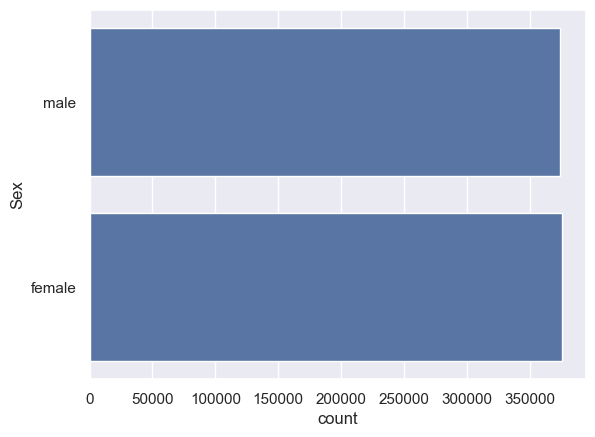

In [45]:
# Plotting the gender column in countplot

sns.countplot(calories_data['Sex'])

C:\Users\USER\AppData\Local\Temp\ipykernel_3192\3983371473.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Age'])


<Axes: xlabel='Age', ylabel='Density'>

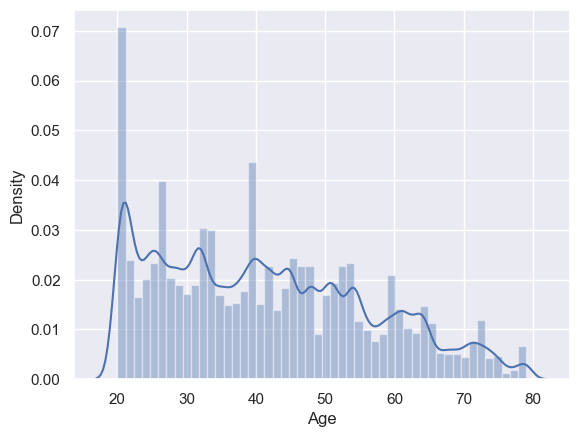

In [46]:
# finding the distribution of the age column

sns.distplot(calories_data['Age'])

In [47]:
# replacing male with - 1 and female with -2

calories_data["Sex"] = calories_data["Sex"].replace({
    "male": 1,
    "female": 0
})

C:\Users\USER\AppData\Local\Temp\ipykernel_3192\2904654453.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  calories_data["Sex"] = calories_data["Sex"].replace({


C:\Users\USER\AppData\Local\Temp\ipykernel_3192\3389096868.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Weight'])


<Axes: xlabel='Weight', ylabel='Density'>

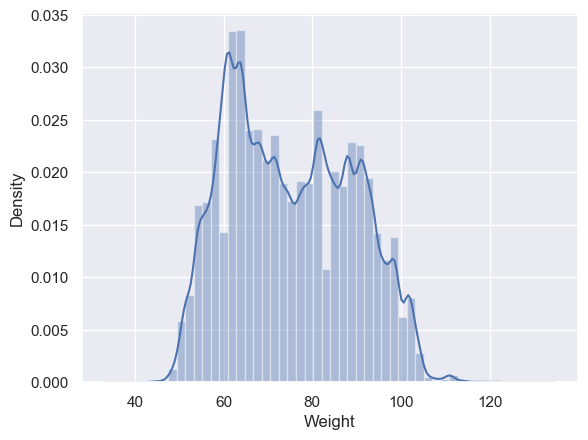

In [48]:
# finding the distribution of the weight column

sns.distplot(calories_data['Weight'])

C:\Users\USER\AppData\Local\Temp\ipykernel_3192\1709007965.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Height'])


<Axes: xlabel='Height', ylabel='Density'>

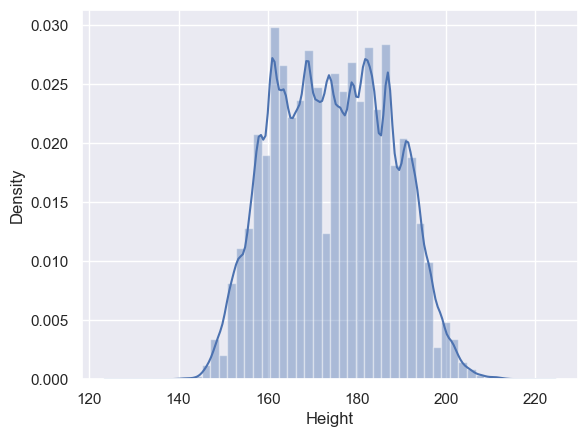

In [49]:
# finding the distribution of the height column

sns.distplot(calories_data['Height'])

C:\Users\USER\AppData\Local\Temp\ipykernel_3192\4215669532.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Duration'])


<Axes: xlabel='Duration', ylabel='Density'>

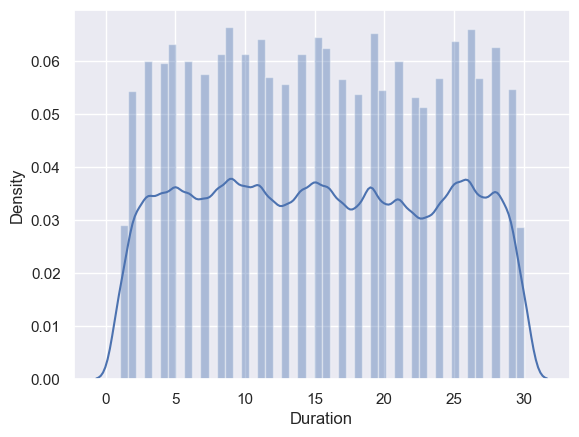

In [50]:
# finding the distribution of the duration column

sns.distplot(calories_data['Duration'])

C:\Users\USER\AppData\Local\Temp\ipykernel_3192\3428338867.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Heart_Rate'])


<Axes: xlabel='Heart_Rate', ylabel='Density'>

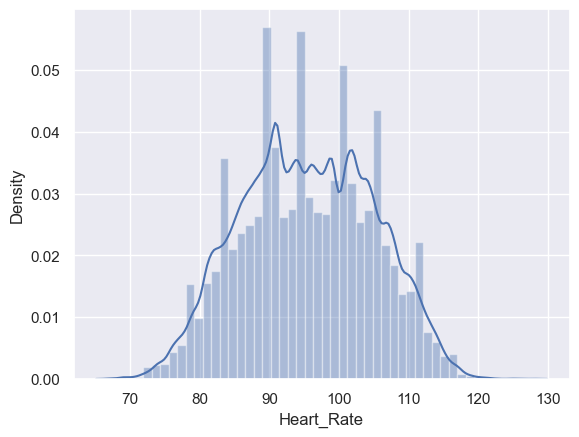

In [51]:
# finding the distribution of the Heart Rate column

sns.distplot(calories_data['Heart_Rate'])

C:\Users\USER\AppData\Local\Temp\ipykernel_3192\1330606612.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(calories_data['Body_Temp'])


<Axes: xlabel='Body_Temp', ylabel='Density'>

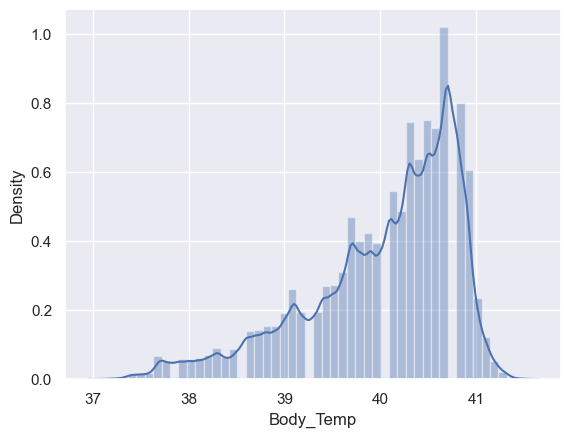

In [52]:
# finding the distribution of the body temp column

sns.distplot(calories_data['Body_Temp'])

# /Finding the correlation in the data set 

In [53]:
correlation = calories_data.corr()

<Axes: >

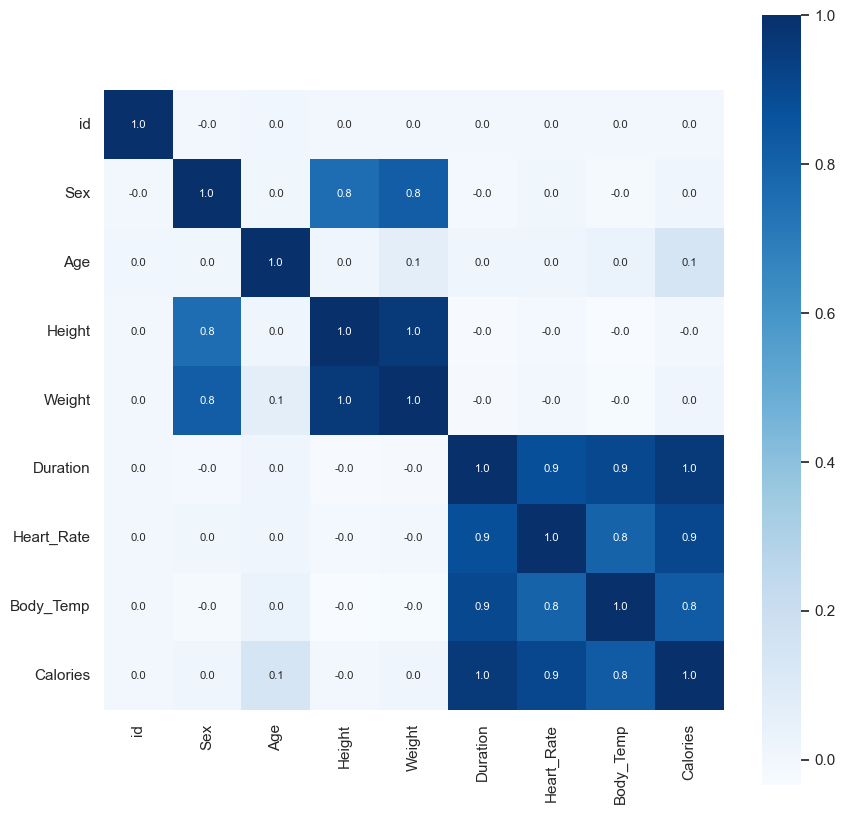

In [56]:
# Constructing a heatmap to understand the correlation

plt.figure(figsize=(10, 10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={"size": 8}, cmap='Blues')

# Splitting our features and target

In [62]:
X = calories_data.drop(columns=['Calories', "id"], axis=1)
Y = calories_data['Calories']

In [63]:
X.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,1,36,189.0,82.0,26.0,101.0,41.0
1,0,64,163.0,60.0,8.0,85.0,39.7
2,0,51,161.0,64.0,7.0,84.0,39.8
3,1,20,192.0,90.0,25.0,105.0,40.7
4,0,38,166.0,61.0,25.0,102.0,40.6


In [64]:
Y.head()

0    150.0
1     34.0
2     29.0
3    140.0
4    146.0
Name: Calories, dtype: float64

# Splitting our data into training and testing data

In [66]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [67]:
print(X.shape, X_train.shape, X_test.shape)

(750000, 7) (600000, 7) (150000, 7)


# Model Training 

* XGBoost Regressor 

In [70]:
# loading the model

model = XGBRegressor()

In [71]:
# Training the model with X_train

model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

# Evaluation

In [75]:
# Prediction on Test data

test_data_prediction =  model.predict(X_test)

print(test_data_prediction)

[113.65607  186.3057   217.00587  ... 196.23756   26.787392  40.85827 ]


### Mean Absolute Error


In [76]:
mae =  metrics.mean_absolute_error(Y_test, test_data_prediction)

In [78]:
print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.3433596724996963
